## 1. Review the Week 4 ML Problem Definition

**Problem definition:** Predict, at or shortly after booking, whether a patient will attend (Attended) or miss (No-Show) their appointment.  

**Candidate features:** `age`, `gender`, `appointment_type`, `booking_lead_days`,
    `previous_appointments`, `previous_no_shows`, `reminder_sent`,
    `reminder_channel`, `distance_to_clinic_km`, `appointment_day`,
    `appointment_time`  
    
**Handling of cancellations:** Cancelled appointments (5.3% of the data) represent a distinct patient action (an active decision communicated in advance) rather than a passive non-attendance. Since the business problem centers specifically on unplanned missed appointments, cancelled rows are proposed to be excluded from the primary model, with the target binarized as Attended vs. No-Show.

**Modelling objective:**

**Resources used:** `HealthConnect_Appointment_Data.csv`, `HealthConnect_Data_Dictionary.xlsx`.

## 2. Data Preparation

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                              classification_report)

In [2]:
# importing dataset
df = pd.read_csv('Downloads/HealthConnect_Appointment_Data.csv')

### Structure & Data Quality

In [3]:
# Shape of the data
print(df.shape)

(5000, 18)


In [4]:
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())

Duplicate appointment_id: 0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# Checking null values 
print(df.isnull().sum())

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64


In [7]:
#confirming data types
print(df.dtypes)

appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object


 ### Handling Cancelled Appointments

In [8]:
print(df['appointment_outcome'].value_counts())

df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['target'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

print("\nModelling subset shape:", df_model.shape)
print(df_model['target'].value_counts(normalize=True).round(3))

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Modelling subset shape: (4737, 19)
target
1    0.512
0    0.488
Name: proportion, dtype: float64


**Decision from Week 4:** Cancelled appointments (263 rows) are excluded from the modelling subset, since they represent a distinct planned action rather than an unplanned no-show. This makes the binary target  well balanced (51.2% / 48.8%).

### Treating missing values

In [9]:
#confirming null values
print(df_model.isnull().sum())

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1285
distance_to_clinic_km      86
waiting_time_minutes       58
appointment_outcome         0
target                      0
dtype: int64


In [10]:
# reminder_channel handling
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('Not Sent')

**Logic:** This is relevant because the missing values are structural. If no reminder was sent, there should be a clear category rather than an a guess.

In [11]:
# distance_to_clinic_km handling
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(
    df_model['distance_to_clinic_km'].median()
)

**Logic:** The missing values here are likely random. Therefore, it would be handled using a central-value imputation. The median of the column provides robust handling.

In [12]:
print(df_model[['reminder_channel','distance_to_clinic_km']].isnull().sum())

reminder_channel         0
distance_to_clinic_km    0
dtype: int64


### Data Type Correction

In [13]:
df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'], format='%m/%d/%Y')
df_model['booking_date'] = pd.to_datetime(df_model['booking_date'], format='%m/%d/%Y')

print(df_model[['appointment_date','booking_date']].dtypes)

appointment_date    datetime64[us]
booking_date        datetime64[us]
dtype: object


### Removing Leakage and Irrelevant Variables    

In [14]:
leakage_and_irrelevant = ['appointment_id', 'patient_id', 'waiting_time_minutes', 'age_group', 'appointment_outcome']
df_model = df_model.drop(columns=leakage_and_irrelevant)

print("Remaining columns:", list(df_model.columns)) 

Remaining columns: ['gender', 'age', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'target']


**Logic:** `appointment_id/patient_id` are identifiers with no predictive value. `waiting_time_minutes`, `age_group` are dropped as they are redundant. `appointment_outcome` is dropped after target was derived from it, to avoid leaking the answer into the feature set.

 ### Checking Categorical Variable. 

In [15]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
for c in cat_cols:
    print(f"\n{c}:")
    print(df_model[c].value_counts())

Categorical columns: ['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel']

gender:
gender
Female               2358
Male                 2274
Prefer not to say     105
Name: count, dtype: int64

appointment_type:
appointment_type
General Consultation       1980
Follow-up                  1344
Specialist Consultation     846
Diagnostic Test             567
Name: count, dtype: int64

appointment_day:
appointment_day
Sunday       704
Friday       696
Wednesday    693
Saturday     683
Tuesday      662
Monday       655
Thursday     644
Name: count, dtype: int64

appointment_time:
appointment_time
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64

reminder_sent:
reminder_sent
Yes    3452
No     1285
Name: count, dtype: int64

reminder_channel:
reminder_channel
SMS         1907
Not Sent    1285
WhatsApp    1039
Email        506
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_11172\2992844902.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


### Data Exploration & Visual Evidence

Each visualization below is followed by an interpretation of what it shows and what decision it informs.

### Numeric feature distributions

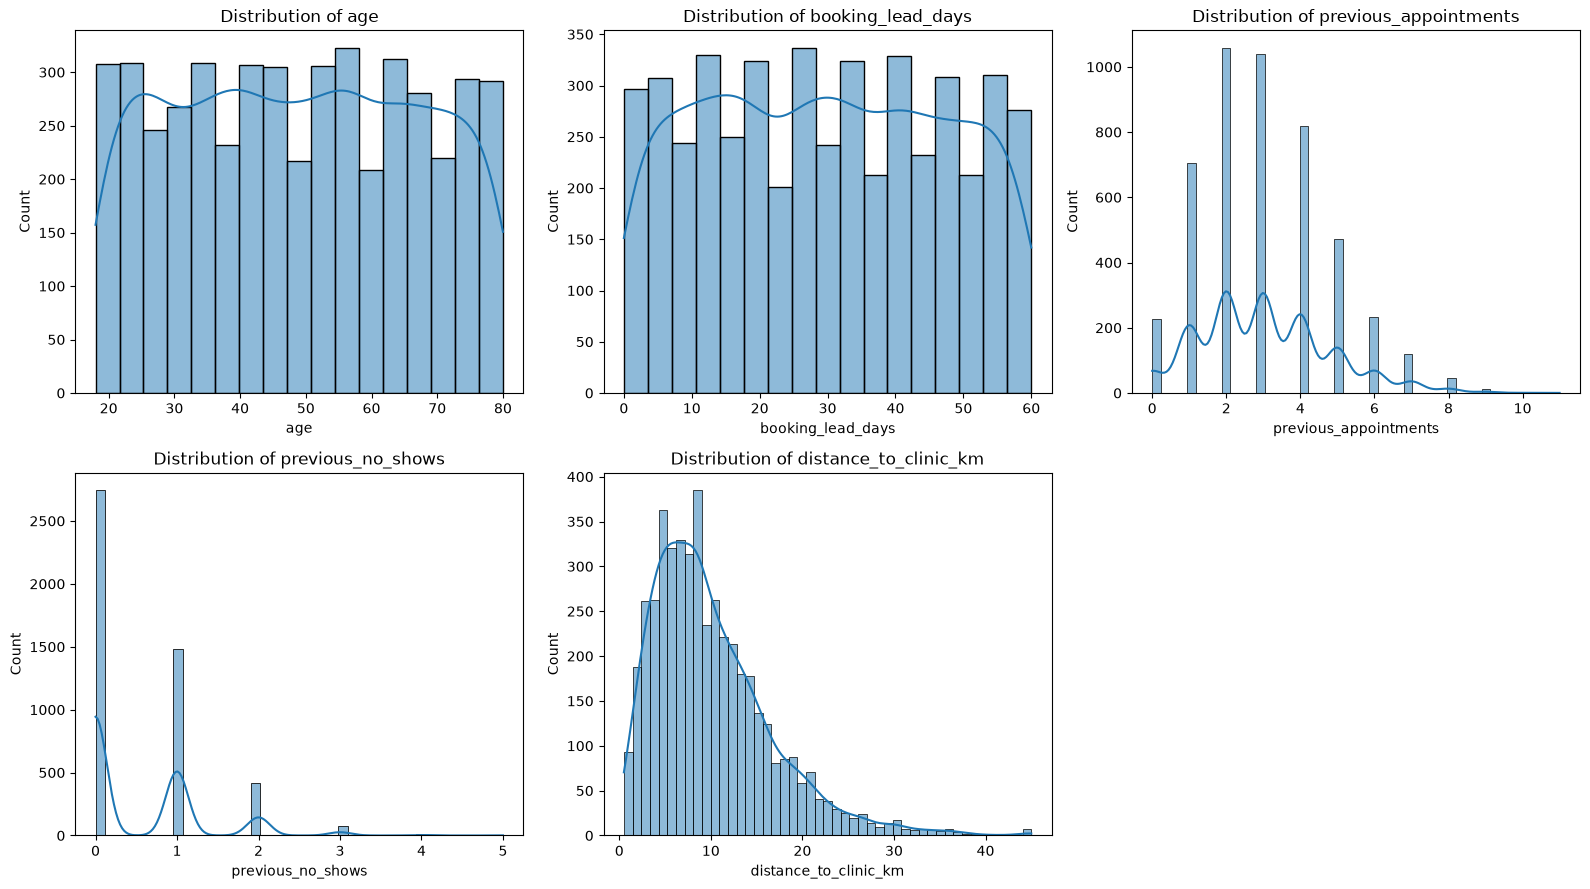

In [16]:
num_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_model[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Findings:** The distributions suggest that `age` and `distance_to_clinic_km` are fairly balanced, while `previous_no_shows` is concentrated at low values, especially 0 and 1. Because of that skew, a rate-based feature is likely more useful than the raw count, since a few patients with unusually high no-show counts could otherwise have too much influence on a linear model.

### Outlier Check

### Boxplots

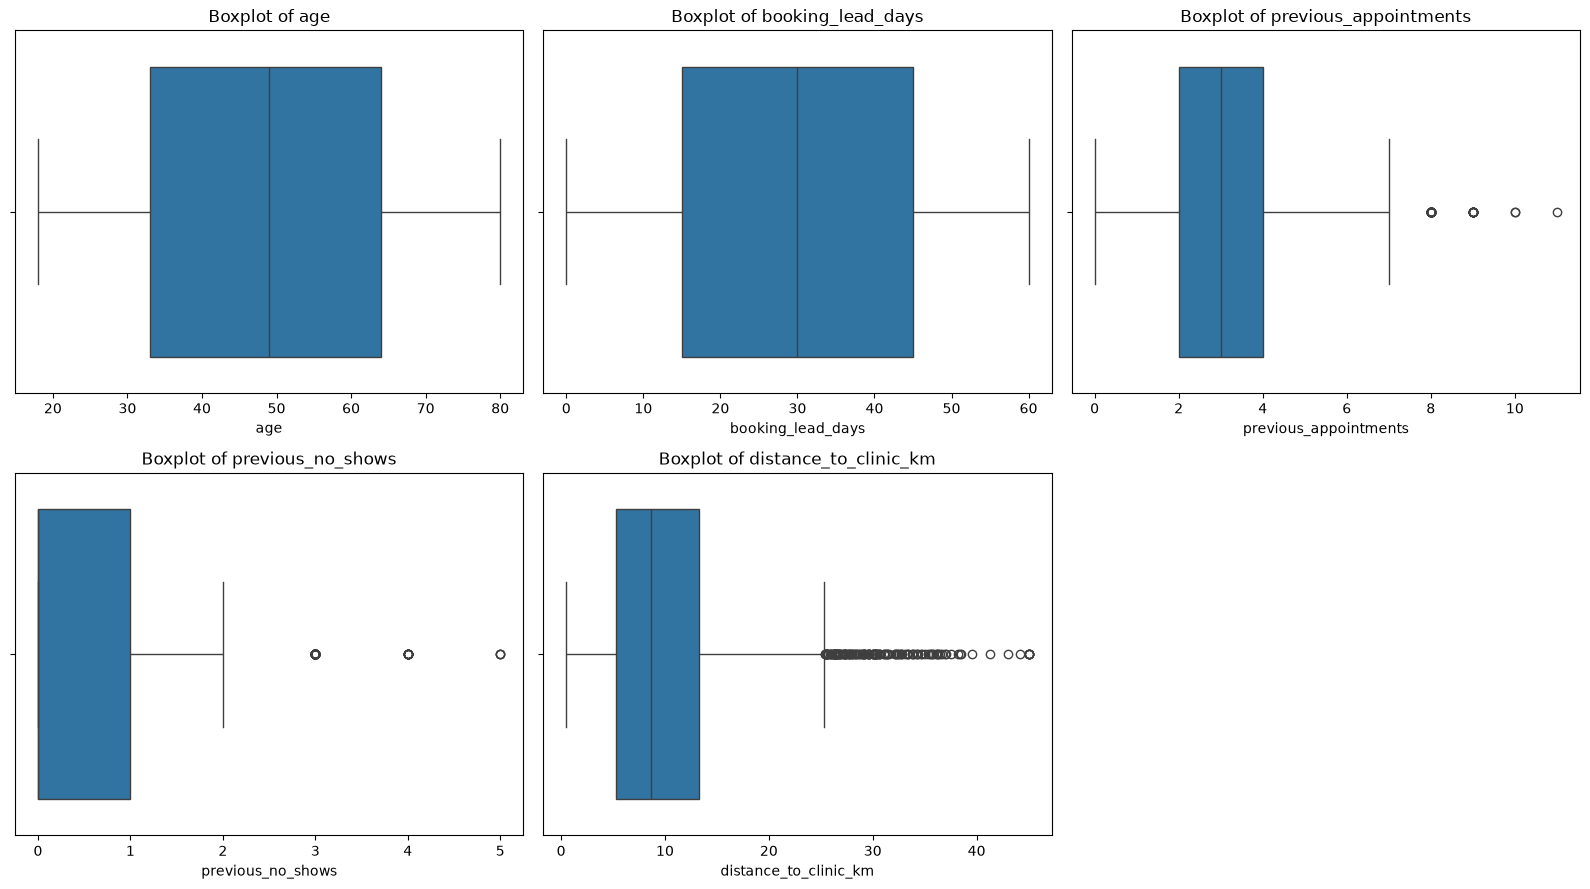

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df_model[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Findings:** No extreme outliers requiring treatment — all numeric fields fall within sensible real-world bounds. No capping/winsorization is applied at this stage.

### Categorical relationships vs Target  

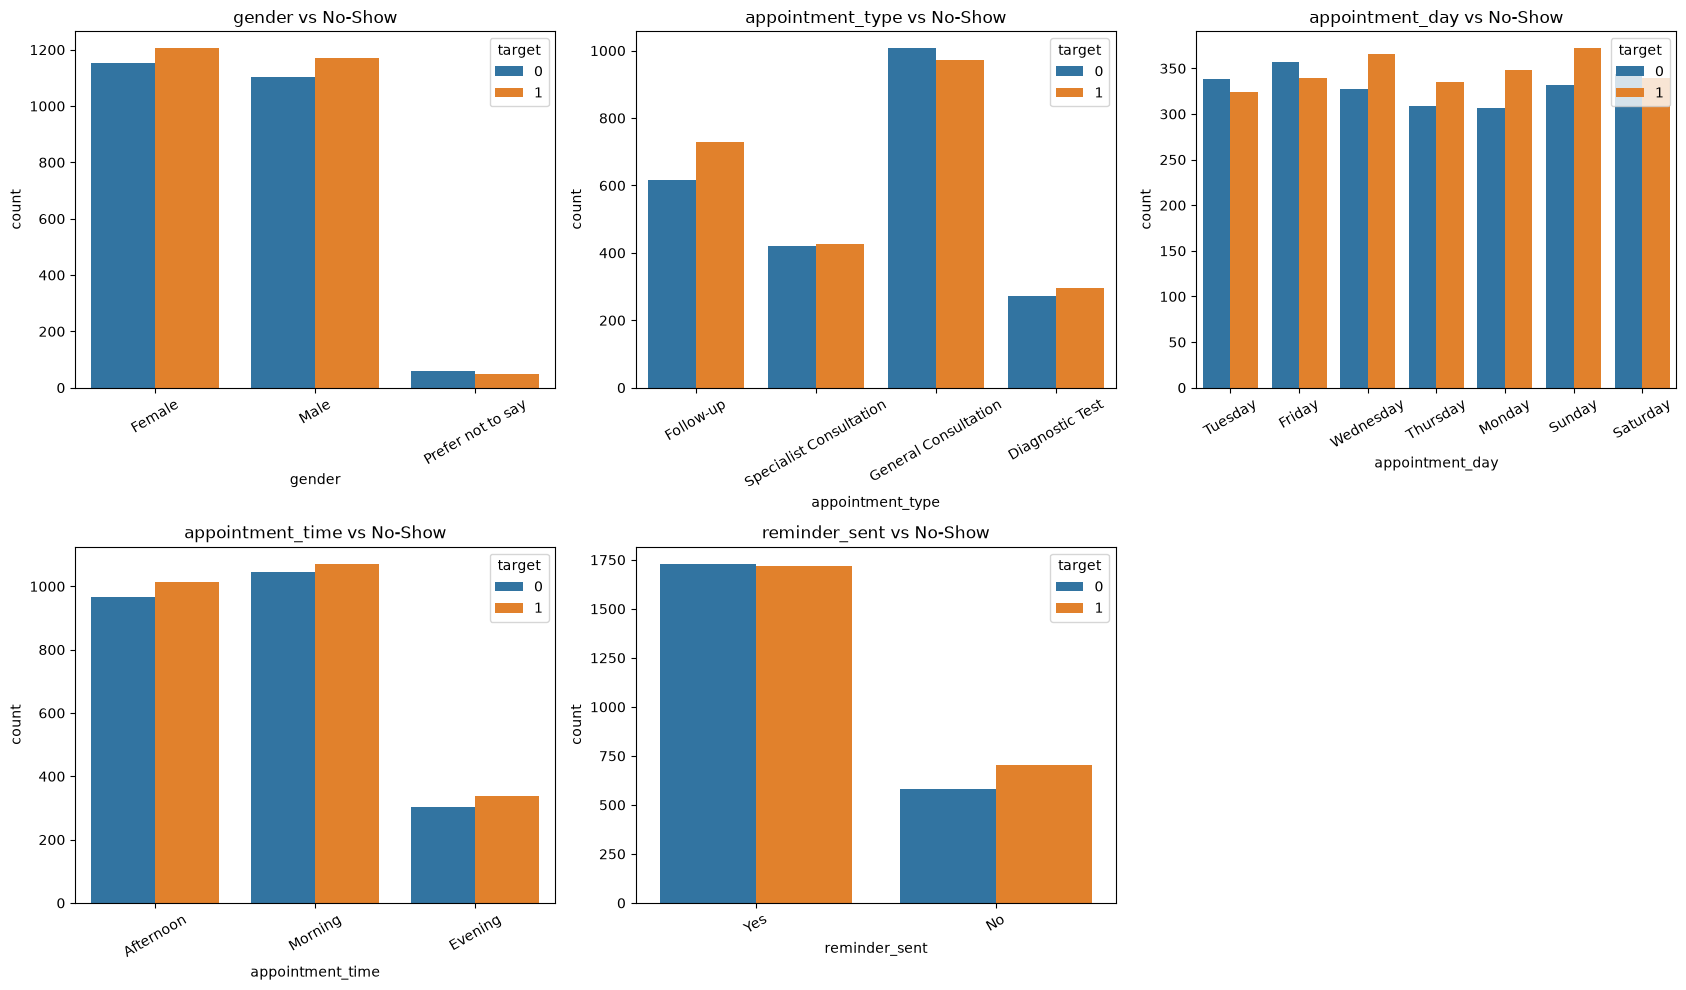

In [18]:
cat_features = ['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='target', data=df_model, ax=axes[i])
    axes[i].set_title(f'{col} vs No-Show')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Analysis:** `reminder_sent` has only a small difference between the no-show and non-no-show groups, so it is a weak standalone predictor. It also supports the broader modelling point that no single categorical feature is decisive, which is why combining several moderate signals in a model is more useful than relying on a single variable.

### Numeric feature vs. target

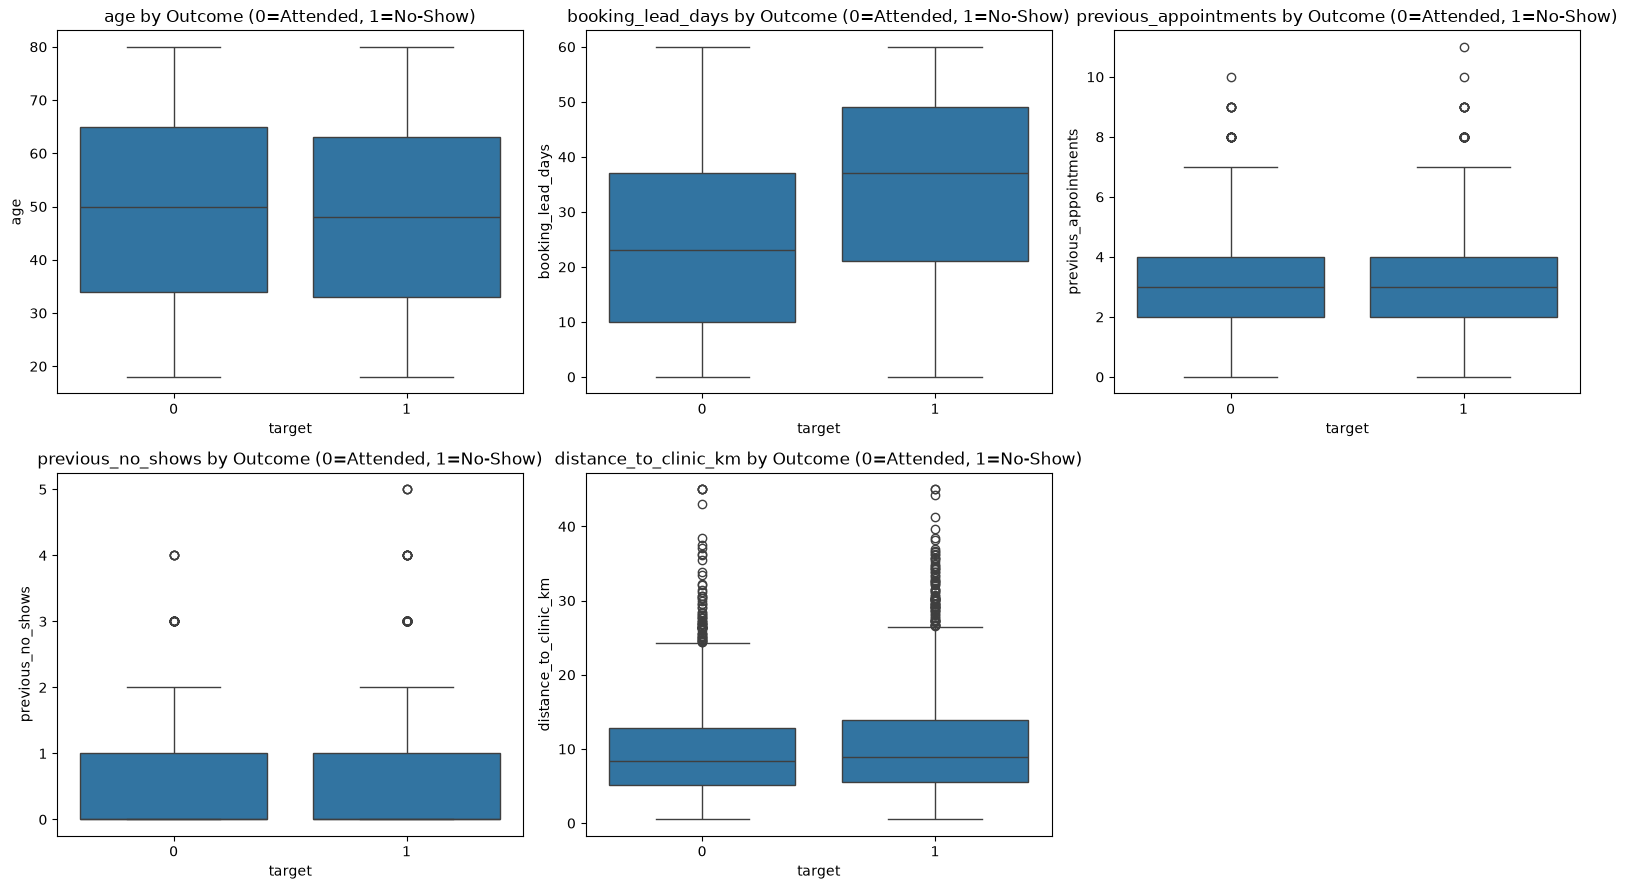

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='target', y=col, data=df_model, ax=axes[i])
    axes[i].set_title(f'{col} by Outcome (0=Attended, 1=No-Show)')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Analysis:** `previous_no_shows` and `booking_lead_days` show the clearest visual separation between classes. This supports prioritizing these two fields and features derived from them in the model.

##  Feature Engineering

Three features are engineered, grounded in the EDA above.

**Feature 1:** `is_new_patient`

In [20]:
df_model['is_new_patient'] = (df_model['previous_appointments'] == 0).astype(int)
print(df_model['is_new_patient'].value_counts())
print(df_model.groupby('is_new_patient')['target'].mean())

is_new_patient
0    4509
1     228
Name: count, dtype: int64
is_new_patient
0    0.514305
1    0.456140
Name: target, dtype: float64


**Summary:** The engineered `is_new_patient` feature is useful because new patients have a lower no-show rate (0.456) than returning patients (0.514), so it adds predictive signal.

**Feature 2:** `prior_no_show_rate`

In [24]:
overall_rate = (df_model['previous_no_shows'].sum() / df_model.loc[df_model['previous_appointments']>0, 'previous_appointments'].sum())
print(f"Dataset-wide prior no-show rate (for new-patient fallback): {overall_rate:.3f}")

df_model['prior_no_show_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['previous_no_shows'] / df_model['previous_appointments'],
    overall_rate
)
print(df_model.groupby('target')['prior_no_show_rate'].mean())

Dataset-wide prior no-show rate (for new-patient fallback): 0.182
target
0    0.155797
1    0.199011
Name: prior_no_show_rate, dtype: float64


**Summary:** The `prior_no_show_rate` feature captures each patient’s past no-show tendency, using a dataset-wide fallback for new patients with no history. The feature is higher for no-shows than for attended appointments, so it appears to be a meaningful predictor and adds useful signal to the model.

**Feature 3:** `lead_time_bucket`

In [25]:
df_model['lead_time_bucket'] = pd.cut(
    df_model['booking_lead_days'],
    bins=[-1, 15, 45, 100],
    labels=['Short','Medium','Long']
)
print(df_model['lead_time_bucket'].value_counts())
print(df_model.groupby('lead_time_bucket', observed=True)['target'].mean())

lead_time_bucket
Medium    2372
Short     1258
Long      1107
Name: count, dtype: int64
lead_time_bucket
Short     0.327504
Medium    0.514755
Long      0.713640
Name: target, dtype: float64


**Summary:** The booking lead time is bucketed into short, medium, and long windows to check whether longer waits are associated with different outcomes. The grouped means differ meaningfully, which would make `lead_time_bucket` a useful feature because appointment delay itself may influence the target.

### Train/Test Strategy

**Decision:** Stratified random 80/20 split.

**Justification:** Appointment outcome rates were checked across the full Jan 2025–Jun 2026 date range and showed no meaningful drift (No-Show rate stayed within roughly 42- 54% every month), so there is no strong case for a time-based split at this baseline stage. Stratification on the target ensures both sets preserve the same ~51/49 class balance, which matters given the moderate dataset size (4,737 rows after excluding Cancelled). A time-based split (train on earlier bookings, test on later ones) is noted as a more production-realistic alternative worth revisiting in Week 6, once deployment considerations become more concrete.

In [27]:
encoded_df = pd.get_dummies(
    df_model.drop(columns=['booking_date','appointment_date']),
    columns=['gender','appointment_type','appointment_day','appointment_time',
             'reminder_sent','reminder_channel','lead_time_bucket'],
    drop_first=True)

X = encoded_df.drop(columns=['target'])
y = encoded_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train target balance:", y_train.mean().round(3), "| Test target balance:", y_test.mean().round(3))

Train shape: (3789, 26) | Test shape: (948, 26)
Train target balance: 0.511 | Test target balance: 0.512


###  Baseline Models

Two models are developed for comparison at the baseline stage:

**Logistic Regression:** — the primary baseline: interpretable  
**Random Forest:** a secondary comparison to check whether the problem has a non-linear structure worth pursuing further

The goal here is a reliable baseline, not the best-performing model.



In [28]:
# Logistic Regression requires scaling; Random Forest does not
scaler = StandardScaler()
numeric_cols_to_scale = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                          'distance_to_clinic_km','prior_no_show_rate']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_scaled[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("Both models trained.")

Both models trained.


### Initial Evauation 

In [29]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.3f}")
    print()

evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)

--- Logistic Regression ---
Accuracy:  0.616
Precision: 0.614
Recall:    0.672
F1-score:  0.642
ROC-AUC:   0.669

--- Random Forest ---
Accuracy:  0.600
Precision: 0.604
Recall:    0.633
F1-score:  0.618
ROC-AUC:   0.635



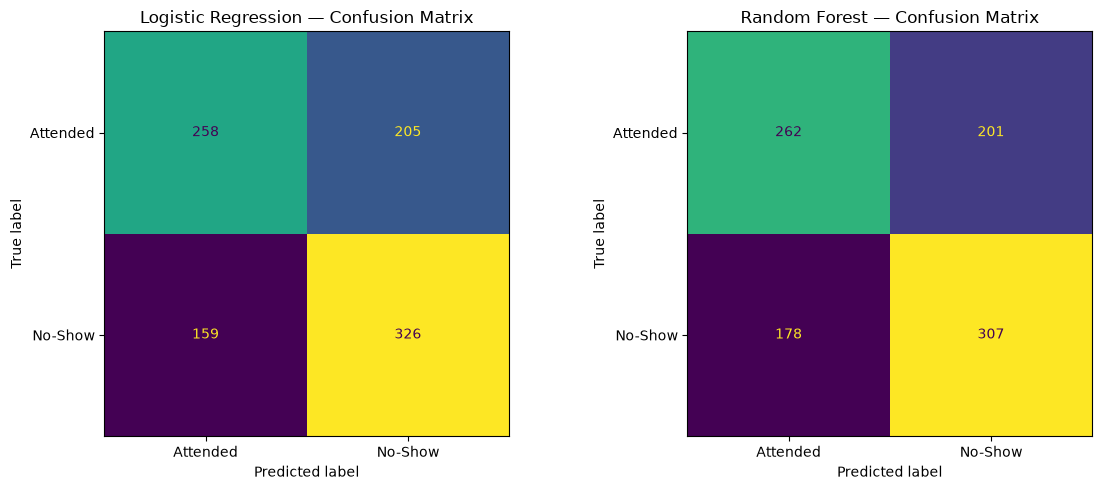

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Attended','No-Show']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Attended','No-Show']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

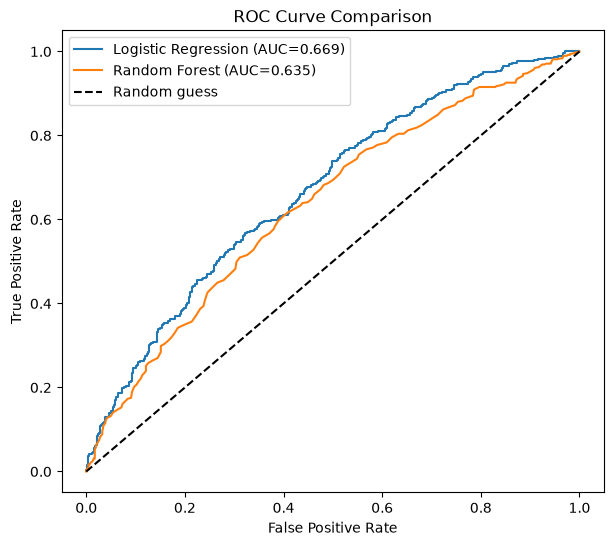

In [31]:
fig, ax = plt.subplots(figsize=(7,6))
for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
ax.plot([0,1],[0,1],'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

In [32]:
# Logistic Regression coefficients — interpretability check
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df.head(10))

                      feature  coefficient
1           booking_lead_days     0.546171
8    gender_Prefer not to say    -0.430824
3           previous_no_shows     0.410098
14     appointment_day_Sunday     0.265949
17  appointment_day_Wednesday     0.263536
25      lead_time_bucket_Long     0.255898
15   appointment_day_Thursday     0.185513
12     appointment_day_Monday     0.184832
4       distance_to_clinic_km     0.172570
20          reminder_sent_Yes    -0.122534


### Interpretation

The results reported above show that both models perform meaningfully above the 0.50 random-guess baseline on ROC AUC, which confirms that the engineered and original features contain real predictive signal. That said, neither model is close to solving the problem, which is expected and appropriate at the baseline stage.

If the Random Forest metrics are close to Logistic Regression, that suggests the relationship is largely linear and the simpler, more interpretable model may be the better choice going into Week 6. If Random Forest performs meaningfully better, that would justify investing more in non-linear approaches next.

### Model Limitations


This is a baseline, not a tuned model, so no hyperparameter search, cross-validation, or feature selection refinement has been applied yet.

The feature set is a manual review rather than a formal feature importance-driven selection process.

Synthetic dataset limitations carried over from Week 4 remain, such as the waiting_time_minutes anomaly, which suggests the data is not fully realistic.

A stratified random split was used instead of a time-based split, so the results may not fully reflect performance on genuinely future, unseen bookings.

### Cross-Track Collaboration Note

**Track interacted with:** Data Analytics

**Information exchanged:** The Data Analytics track's Week 4 initial data quality assessment and proposed KPIs around no-show rate by reminder status and distance to clinic directly informed which features were prioritized for engineering in this notebook (`prior_no_show_rate`, `lead_time_bucket`).

**Why relevant:** Data Analytics' business-question framing helps ground which technical features are likely to matter to clinic stakeholders, not just which are statistically convenient.

**What changed as a result:** Confirmed `reminder_sent`/`reminder_channel` and `distance_to_clinic_km` as retained candidate features rather than deprioritizing them despite their comparatively mild individual effect sizes.



### Recommendations for Week 6

1. Formal feature importance analysis (e.g., permutation importance) on the Random Forest model to prioritize which engineered features earn their place
2. Hyperparameter tuning for whichever baseline shows more promise
3. Revisit train/test strategy — test a time-based split to assess how much performance changes under a more production-realistic setup
4. Coordinate with the Machine Learning Engineering track on what output format (probability score vs. binary label) their pipeline expects, before finalizing the model interface